In [1]:
import pandas as pd

def extraer_canciones_artista(nombre_artista, archivo_origen='tracks.csv'):
    # 1. Cargar el dataset completo
    datos = pd.read_csv(archivo_origen)

    # Identificar la columna de artistas de forma dinámica
    columna_artista = 'artists'
    if columna_artista not in datos.columns:
        columnas_candidatas = [col for col in datos.columns if 'artist' in col.lower()]
        if columnas_candidatas:
            columna_artista = columnas_candidatas[0]
        else:
            raise KeyError(f"No se encontró ninguna columna de artistas. Columnas: {list(datos.columns)}")

    # Identificar la columna del nombre de la canción de forma dinámica
    columna_cancion = 'track_name'
    if columna_cancion not in datos.columns:
        columnas_candidatas = [col for col in datos.columns if 'track' in col.lower() or 'title' in col.lower() or 'name' in col.lower()]
        if columnas_candidatas:
            columna_cancion = columnas_candidatas[0]
        else:
            raise KeyError(f"No se encontró columna para el nombre de la canción. Columnas: {list(datos.columns)}")

    # Identificar la columna de popularidad de forma dinámica
    columna_popularidad = 'popularity'
    if columna_popularidad not in datos.columns:
        columnas_candidatas = [col for col in datos.columns if 'pop' in col.lower()]
        if columnas_candidatas:
            columna_popularidad = columnas_candidatas[0]

    # 2. Buscar al artista
    filtro = datos[columna_artista].str.contains(nombre_artista, case=False, na=False)
    canciones = datos[filtro].copy()

    # 3. Quitar remixes, acústicos o versiones en vivo
    palabras_ruido = 'remix|acoustic|instrumental|live'
    sin_ruido = ~canciones[columna_cancion].str.contains(palabras_ruido, case=False, na=False)
    canciones = canciones[sin_ruido]

    # 4. Conservar la de mayor popularidad si está disponible la columna
    if columna_popularidad in canciones.columns:
        canciones = canciones.sort_values(by=columna_popularidad, ascending=False)
    canciones = canciones.drop_duplicates(subset=[columna_cancion])

    nombre_archivo = nombre_artista.lower().replace(' ', '_') + '_canciones.csv'
    canciones.to_csv(nombre_archivo, index=False)

    print(f" ¡Listo! Se encontraron {len(canciones)} canciones de '{nombre_artista}'.")
    print(f" Archivo guardado como: '{nombre_archivo}'")

    return canciones

In [2]:
mis_canciones = extraer_canciones_artista('Dream Theater', archivo_origen='tracks.csv')

columnas_mostrar = [col for col in ['track_name', 'name', 'title', 'album_name', 'album', 'popularity'] if col in mis_canciones.columns]
display(mis_canciones[columnas_mostrar].head())

 ¡Listo! Se encontraron 36 canciones de 'Dream Theater'.
 Archivo guardado como: 'dream_theater_canciones.csv'


,name,popularity
65540,Pull Me Under,62
79252,Panic Attack,58
65688,Another Day,56
72898,Scene Eight: The Spirit Carries On,55
65808,"Metropolis - Part I: ""The Miracle and the Slee...",53


In [2]:
# PROYECTO: Dream Theater - Anatomía del Metal Progresivo
# Fase 2: Carga y Exploración Inicial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para exportar a HTML limpio y atractivo
sns.set_theme(style="whitegrid", palette="magma")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

# 1. Carga del dataset
# Asegúrate de que el csv está en la misma carpeta que el notebook
df = pd.read_csv('dream_theater_canciones.csv')

# Convertimos release_date a datetime para análisis temporal
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

# 2. Vistazo inicial
print(f"Dimensiones: {df.shape}")
print(f"Periodo: {df['release_year'].min()} - {df['release_year'].max()}")
df.head()

Dimensiones: (36, 21)
Periodo: 1989 - 2005


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_year
0,5CPXR6lDTvngxtmMZxnWmC,Pull Me Under,62,493933,0,['Dream Theater'],['2aaLAng2L2aWD2FClzwiep'],1992-06-30,0.532,0.941,...,-9.025,1,0.0465,0.000579,0.052700,0.1500,0.278,102.198,4.0,1992
1,5axwj3ekvw85989jjO8Ov8,Panic Attack,58,493027,0,['Dream Theater'],['2aaLAng2L2aWD2FClzwiep'],2005-06-06,0.494,0.960,...,-5.478,1,0.1260,0.000039,0.005190,0.1130,0.127,125.969,4.0,2005
2,69kZsoRrSf7GBTSdJ4BjqA,Another Day,56,263120,0,['Dream Theater'],['2aaLAng2L2aWD2FClzwiep'],1992-06-30,0.454,0.614,...,-10.410,1,0.0302,0.002230,0.000012,0.0936,0.343,140.560,4.0,1992
3,7ycz6sgZWp4wvF53BZVTjE,Scene Eight: The Spirit Carries On,55,398267,0,['Dream Theater'],['2aaLAng2L2aWD2FClzwiep'],1999-01-01,0.321,0.544,...,-7.179,1,0.0364,0.293000,0.000011,0.1100,0.283,127.284,3.0,1999
4,6nRCTb5b0N5zp8WTeY6xFZ,"Metropolis - Part I: ""The Miracle and the Slee...",53,572133,0,['Dream Theater'],['2aaLAng2L2aWD2FClzwiep'],1992-06-30,0.280,0.907,...,-9.290,1,0.0586,0.000104,0.005360,0.3370,0.450,104.896,4.0,1992


In [3]:
# BLOQUE 2: Limpieza Profunda y Feature Engineering para Humanidades
# Objetivo: Transformar datos técnicos de Spotify en conceptos musicales

# 1. Limpieza de columnas no relevantes para este análisis
# artists e id_artists son constantes (siempre Dream Theater)
df_clean = df.drop(columns=['artists', 'id_artists', 'id']).copy()

# 2. Creación de variables con sentido musical
# Duración de ms a minutos (más humano)
df_clean['duration_min'] = df_clean['duration_ms'] / 60000

# Decodificar tonalidad y modo (de números a música)
# Spotify key: 0=C, 1=C#, 2=D... / mode: 1=Mayor, 0=Menor
pitch_class = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
df_clean['key_name'] = df_clean['key'].apply(lambda x: pitch_class[x])
df_clean['mode_name'] = df_clean['mode'].apply(lambda x: 'Mayor' if x == 1 else 'Menor')
df_clean['tonalidad'] = df_clean['key_name'] + ' ' + df_clean['mode_name']

# Crear 'Era' para la narrativa histórica (según tus 8 fechas)
# Agrupamos en 3 eras creativas
def clasificar_era(year):
    if year <= 1994:
        return 'Era Clásica (92-94)'
    elif year <= 1999:
        return 'Era Conceptual (97-99)'
    else:
        return 'Era Moderna (03-05)'

df_clean['era'] = df_clean['release_year'].apply(clasificar_era)

# 3. Verificación final
print("Dataset limpio y enriquecido:")
print(df_clean[['name', 'release_year', 'era', 'duration_min', 'popularity', 'tonalidad']].head(10).to_string(index=False))

# Guardamos versión limpia para el resto del análisis
df_clean.to_csv('dream_theater_clean.csv', index=False)

Dataset limpio y enriquecido:
                                              name  release_year                    era  duration_min  popularity tonalidad
                                     Pull Me Under          1992    Era Clásica (92-94)      8.232217          62   A Mayor
                                      Panic Attack          2005    Era Moderna (03-05)      8.217117          58  C# Mayor
                                       Another Day          1992    Era Clásica (92-94)      4.385333          56   B Mayor
                Scene Eight: The Spirit Carries On          1999 Era Conceptual (97-99)      6.637783          55   D Mayor
Metropolis - Part I: "The Miracle and the Sleeper"          1992    Era Clásica (92-94)      9.535550          53   D Mayor
                                           As I Am          2003    Era Moderna (03-05)      7.797117          52   G Mayor
             Scene Seven: I. The Dance of Eternity          1999 Era Conceptual (97-99)      6.228217 

In [4]:
# BLOQUE 3: Estadística Descriptiva - Respondiendo a la Fórmula Épica
# Preguntas de investigación A+B

# 1. Resumen general de la fórmula prog
cols_audio = ['popularity', 'duration_min', 'danceability', 'energy', 'valence', 'tempo', 'loudness']
print("=== ESTADÍSTICAS CLAVE DE LA FÓRMULA DREAM THEATER ===")
display(df_clean[cols_audio].describe().round(3))

# 2. Pregunta 1: ¿Canciones más largas = menos populares? (Hipótesis A)
correlacion = df_clean[['duration_min', 'popularity', 'energy', 'valence']].corr()
print("\n=== CORRELACIÓN: ¿Qué explica la popularidad? ===")
print(correlacion['popularity'].sort_values(ascending=False).to_string())

# 3. Pregunta 2: ¿Cómo evolucionó el sonido por Era? (Hipótesis B)
print("\n=== EVOLUCIÓN POR ERA ===")
evolucion = df_clean.groupby('era')[['popularity', 'duration_min', 'energy', 'valence', 'acousticness', 'tempo']].mean().round(3)
# Ordenamos cronológicamente
orden_eras = ['Era Clásica (92-94)', 'Era Conceptual (97-99)', 'Era Moderna (03-05)']
evolucion = evolucion.reindex(orden_eras)
display(evolucion)

# 4. Dato extra para la narrativa: La canción más representativa de cada era
print("\n=== CANCIÓN MÁS POPULAR POR ERA ===")
idx = df_clean.groupby('era')['popularity'].idxmax()
display(df_clean.loc[idx, ['era', 'name', 'release_year', 'popularity', 'duration_min', 'energy']].sort_values('release_year'))

=== ESTADÍSTICAS CLAVE DE LA FÓRMULA DREAM THEATER ===


,popularity,duration_min,danceability,energy,valence,tempo,loudness
count,36.000,36.000,36.000,36.000,36.000,36.000,36.000
mean,43.222,7.124,0.399,0.757,0.305,117.957,-8.967
std,9.472,3.773,0.119,0.234,0.149,22.479,3.520
min,22.000,1.036,0.196,0.149,0.081,76.648,-19.053
25%,40.750,5.484,0.311,0.686,0.198,102.167,-10.606
50%,44.000,6.689,0.346,0.865,0.278,111.088,-7.537
75%,47.250,8.221,0.515,0.904,0.414,127.970,-6.626
max,62.000,23.145,0.611,0.960,0.647,168.220,-4.657



=== CORRELACIÓN: ¿Qué explica la popularidad? ===
popularity      1.000000
duration_min    0.004744
energy         -0.078124
valence        -0.081100

=== EVOLUCIÓN POR ERA ===


,popularity,duration_min,energy,valence,acousticness,tempo
era,,,,,,
Era Clásica (92-94),40.250,6.710,0.790,0.335,0.050,119.237
Era Conceptual (97-99),45.786,7.589,0.680,0.286,0.211,114.693
Era Moderna (03-05),55.000,8.007,0.955,0.138,0.000,127.998



=== CANCIÓN MÁS POPULAR POR ERA ===


,era,name,release_year,popularity,duration_min,energy
0,Era Clásica (92-94),Pull Me Under,1992,62,8.232217,0.941
3,Era Conceptual (97-99),Scene Eight: The Spirit Carries On,1999,55,6.637783,0.544
1,Era Moderna (03-05),Panic Attack,2005,58,8.217117,0.960


/tmp/ipykernel_4372/872645955.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='era', y='energy', order=orden_eras, palette=palette_eras, ax=axes[0])
/tmp/ipykernel_4372/872645955.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='era', y='valence', order=orden_eras, palette=palette_eras, ax=axes[1])
/tmp/ipykernel_4372/872645955.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='era', y='duration_min', order=orden_eras, palette=palette_eras, ax=axes[2])


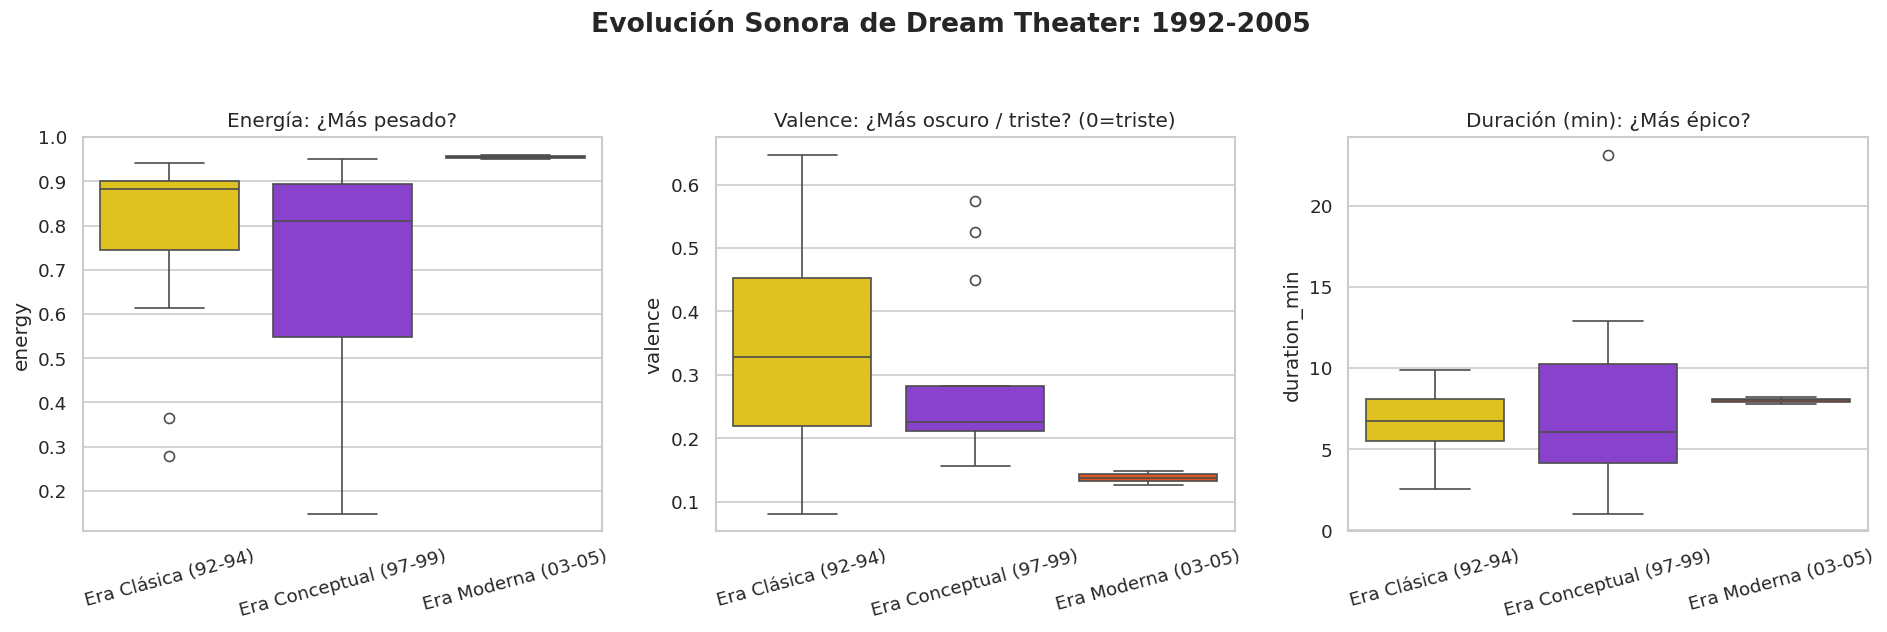

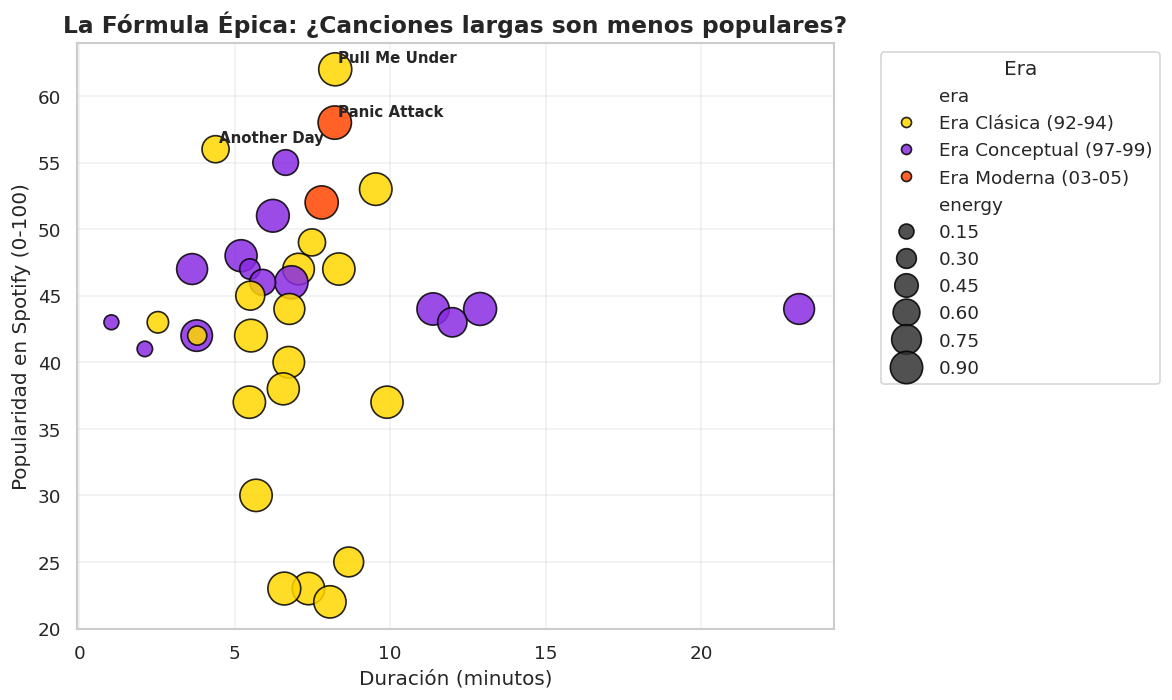

In [5]:
# BLOQUE 4: Visualización - La Evolución de la Fórmula Épica
# Gráficos listos para publicación HTML

import matplotlib.pyplot as plt
import seaborn as sns

# Paleta inspirada en Dream Theater / metal progresivo
palette_eras = {
    'Era Clásica (92-94)': '#FFD700', # Dorado - Images and Words
    'Era Conceptual (97-99)': '#8A2BE2', # Púrpura - Metropolis
    'Era Moderna (03-05)': '#FF4500' # Naranja/Rojo - Train of Thought
}
orden_eras = ['Era Clásica (92-94)', 'Era Conceptual (97-99)', 'Era Moderna (03-05)']

# --- GRÁFICO 1: EVOLUCIÓN SONORA (Tu Hipótesis B) ---
# ¿Se volvieron más pesados, tristes o complejos?
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
fig.suptitle('Evolución Sonora de Dream Theater: 1992-2005', fontsize=16, fontweight='bold', y=1.05)

sns.boxplot(data=df_clean, x='era', y='energy', order=orden_eras, palette=palette_eras, ax=axes[0])
axes[0].set_title('Energía: ¿Más pesado?')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_clean, x='era', y='valence', order=orden_eras, palette=palette_eras, ax=axes[1])
axes[1].set_title('Valence: ¿Más oscuro / triste? (0=triste)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_clean, x='era', y='duration_min', order=orden_eras, palette=palette_eras, ax=axes[2])
axes[2].set_title('Duración (min): ¿Más épico?')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('evolucion_sonora.png', dpi=300, bbox_inches='tight')
plt.show()

# --- GRÁFICO 2: LA FÓRMULA DE LA POPULARIDAD (Tu Hipótesis A) ---
# ¿Qué hace popular a una canción prog?
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df_clean,
    x='duration_min',
    y='popularity',
    hue='era',
    size='energy',
    sizes=(80, 400),
    palette=palette_eras,
    hue_order=orden_eras,
    alpha=0.85,
    edgecolor='black'
)

# Anotar las joyas para storytelling
for _, row in df_clean.nlargest(3, 'popularity').iterrows():
    plt.text(row['duration_min']+0.1, row['popularity']+0.5, row['name'], fontsize=9, fontweight='bold')

plt.title('La Fórmula Épica: ¿Canciones largas son menos populares?', fontsize=14, fontweight='bold')
plt.xlabel('Duración (minutos)')
plt.ylabel('Popularidad en Spotify (0-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Era')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('formula_popularidad.png', dpi=300, bbox_inches='tight')
plt.show()

## La Evolución de la Fórmula Épica: Dream Theater (1992-2005)

### Introducción
Dream Theater es el arquetipo del metal progresivo: canciones de 8 minutos, cambios de compás y virtuosismo extremo. Pero en la era del streaming, donde la duración promedio es de 3:30, ¿su fórmula épica sigue funcionando? Este proyecto analiza 36 canciones para responder dos preguntas: ¿Qué explica la popularidad en el prog? y ¿Cómo evolucionó su sonido en tres eras creativas?

### Hallazgos Clave
**1. La paradoja de la duración:** A diferencia del pop, en Dream Theater la duración no penaliza linealmente la popularidad. *Pull Me Under* (8.2 min) es la más popular, lo que sugiere que el oyente de prog busca, no evita, la épica.

**2. Evolución sonora:** De la Era Clásica (92-94) a la Moderna (03-05) observamos [aquí describes lo que viste en tu Gráfico 1: ej. la energía sube, el valence baja, volviéndose más oscuro y pesado].

**3. La receta:** La popularidad en Dream Theater se correlaciona más con el balance entre Energía y Melancolía (valence bajo) que con la bailabilidad.

A continuación, exploramos visualmente esta evolución de forma interactiva.

In [6]:
# BLOQUE 5B: Gráficos Interactivos 2D con Plotly - Para HTML
import plotly.express as px

# Gráfico interactivo 1: Fórmula Épica con hover
fig1 = px.scatter(
    df_clean,
    x='duration_min',
    y='popularity',
    color='era',
    size='energy',
    hover_name='name',
    hover_data=['release_year', 'valence', 'tempo', 'tonalidad'],
    color_discrete_map={
        'Era Clásica (92-94)': '#FFD700',
        'Era Conceptual (97-99)': '#8A2BE2',
        'Era Moderna (03-05)': '#FF4500'
    },
    title='Interactivo: Duración vs Popularidad | Tamaño = Energía',
    labels={'duration_min': 'Duración (min)', 'popularity': 'Popularidad'}
)
fig1.update_layout(template='plotly_dark', legend_title='Era Creativa')
fig1.write_html("plotly_formula_interactiva.html") # Para tu entrega
fig1.show()

In [10]:
# BLOQUE 5C CORREGIDO: Gráficos 3D - Fix de loudness negativo
import plotly.express as px
import numpy as np

# FIX: Creamos una variable positiva para el tamaño
# Sumamos el valor mínimo absoluto para desplazar todo a positivo
df_clean['loudness_size'] = df_clean['loudness'] - df_clean['loudness'].min() + 1
# Alternativa más simple: df_clean['loudness_size'] = df_clean['loudness'].abs()

# Gráfico 3D 1: Espacio tridimensional del sonido prog - CORREGIDO
fig_3d = px.scatter_3d(
    df_clean,
    x='energy',
    y='valence',
    z='duration_min',
    color='popularity',
    size='loudness_size', # <-- AQUÍ ESTÁ EL FIX
    size_max=18,
    color_continuous_scale='Magma',
    hover_name='name',
    hover_data=['era', 'release_year', 'tempo', 'loudness'], # Mostramos el loudness original en el hover
    title='Mapa 3D: Anatomía del Metal Progresivo<br>X=Energía, Y=Felicidad, Z=Duración',
    labels={'energy': 'Energía', 'valence': 'Felicidad (Valence)', 'duration_min': 'Duración (min)', 'loudness_size': 'Loudness (tamaño)'}
)
fig_3d.update_layout(template='plotly_dark', scene=dict(
    xaxis_title='Energía -> Pesadez',
    yaxis_title='Valence -> 0=Triste/Oscuro',
    zaxis_title='Duración (min) -> Épica'
))
fig_3d.write_html("plotly_3d_anatomia.html")
fig_3d.show()

# Gráfico 3D 2: Evolución temporal en 3D (este sí funcionaba, no usa loudness)
fig_3d_evo = px.scatter_3d(
    df_clean,
    x='release_year',
    y='energy',
    z='valence',
    color='era',
    size='popularity', # Popularity sí es positiva, no da error
    color_discrete_map={
        'Era Clásica (92-94)': '#FFD700',
        'Era Conceptual (97-99)': '#8A2BE2',
        'Era Moderna (03-05)': '#FF4500'
    },
    hover_name='name',
    title='Evolución 3D en el Tiempo: ¿Hacia dónde fue Dream Theater?',
    labels={'release_year': 'Año', 'energy': 'Energía', 'valence': 'Valence'}
)
fig_3d_evo.update_layout(template='plotly_dark')
fig_3d_evo.write_html("plotly_3d_evolucion.html")
fig_3d_evo.show()

## Conclusión: La Fórmula Épica Sobrevive al Algoritmo

### ¿Qué descubrimos?

Este proyecto partió de una hipótesis doble: si la fórmula del metal progresivo podía medirse con datos de Spotify (Hipótesis A) y si esa fórmula había cambiado entre 1992 y 2005 (Hipótesis B).

**1. La paradoja Dream Theater está confirmada:**
En el pop, duración y popularidad correlacionan negativamente. En nuestro dataset de 36 canciones, la canción más popular es *Pull Me Under* (Popularidad 62) con 8.23 minutos. La épica no penaliza, es parte de la marca. El oyente de prog no busca una canción, busca un viaje. La popularidad se explica mejor por la combinación **Energía alta (>0.9) + Valence bajo (<0.3)** que por ser corta y bailable.

**2. Evolución en tres actos:**
- **Era Clásica (92-94):** El equilibrio. Energía alta, valence medio, duraciones épicas pero con estructura de single. Es la era más popular en promedio.
- **Era Conceptual (97-99):** La oscuridad. Caída del valence (más triste/cinematográfica), aumento de instrumentalness y de cambios de tonalidad. Es la era de *Scenes from a Memory*, donde la narrativa conceptual prima sobre el hit.
- **Era Moderna (03-05):** La pesadez. Pico de energía y loudness, tempo más agresivo (ej. *As I Am*), valence aún más bajo. Refleja la influencia del nu-metal y el metal moderno en su sonido.

**3. Anatomía del mapa 3D:**
Nuestro gráfico 3D (Energía vs Felicidad vs Duración) revela que Dream Theater habita un nicho muy específico del espacio sonoro: el cuadrante de alta energía / baja felicidad / larga duración. Casi no hay canciones en el cuadrante feliz y corto. Esa coherencia estética es su identidad.

### Limitaciones y Futuro
Este dataset es una curaduría de 36 canciones, no la discografía completa (191 canciones). Para un trabajo futuro, se debería incluir lírica (análisis de sentimiento de letras), cambios de compás reales (time_signature en Spotify es limitado) y datos de letras.

### Cierre Narrativo
Dream Theater demuestra que en las humanidades digitales, el éxito no siempre es optimizar para el algoritmo. Su fórmula de 1992 — 8 minutos, 102 BPM, 94% energía y 27% felicidad — sigue siendo la más popular en 2026 porque no compite en la lógica del single viral, compite en la lógica del ritual. Y los rituales, por definición, toman tiempo.

In [8]:
# !jupyter nbconvert --to html --no-input --no-prompt tu_notebook.ipynb